# 第080课 半监督与弱监督
固定预算与噪声，保留所有配置，不用测试标签选择参数。

{
  "ratios": [
    0.02,
    0.1,
    0.3
  ],
  "nominal_noise_probabilities": [
    0.0,
    0.25,
    0.5
  ],
  "seeds": [
    7,
    19,
    31,
    43,
    59
  ],
  "threshold": 0.8,
  "pseudo_weight": 0.5,
  "rounds": 5,
  "l2": 0.05,
  "test_selection": "none; all predetermined conditions reported",
  "validation_usage": "reserved; no tuning in frozen experiment"
}


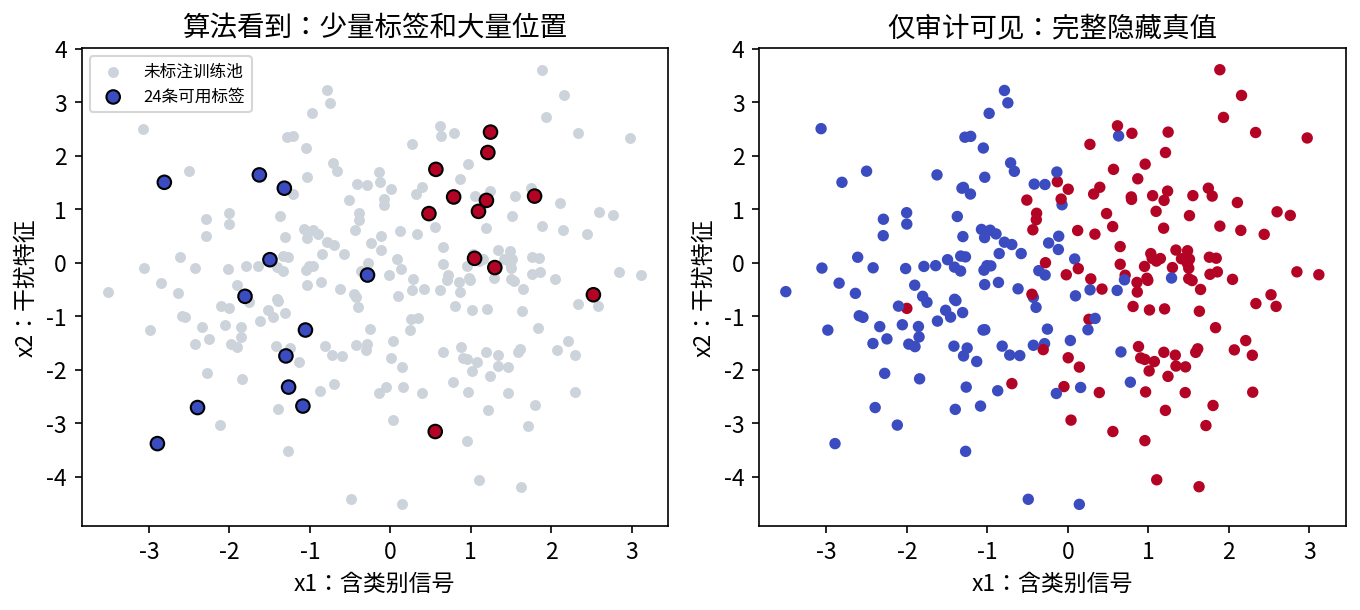

In [1]:
import json, numpy as np
from experiment import run,stress_experiment
from supervision import *
from IPython.display import display, Image
r=run()
print(json.dumps(r['protocol'],ensure_ascii=False,indent=2))
display(Image(filename='figures/01_information.png'))

## 1 全部预定配置与不可训练条件

{'ratio': 0.02, 'noise': 0.0, 'valid_seeds': 5, 'supervised_mean_accuracy': 0.7933333333333332, 'pseudo_mean_accuracy': 0.7826666666666668, 'mean_accuracy_change': -0.010666666666666647, 'change_std_ddof1': 0.027603341182625807, 'mean_pseudo_error_rate': 0.15062751276793027}
{'ratio': 0.02, 'noise': 0.25, 'valid_seeds': 4, 'supervised_mean_accuracy': 0.59625, 'pseudo_mean_accuracy': 0.5758333333333333, 'mean_accuracy_change': -0.020416666666666652, 'change_std_ddof1': 0.09204844738868041, 'mean_pseudo_error_rate': 0.4050220165660466}
{'ratio': 0.02, 'noise': 0.5, 'valid_seeds': 5, 'supervised_mean_accuracy': 0.3443333333333333, 'pseudo_mean_accuracy': 0.3976666666666667, 'mean_accuracy_change': 0.05333333333333333, 'change_std_ddof1': 0.10789655539759677, 'mean_pseudo_error_rate': 0.625976223994713}
{'ratio': 0.1, 'noise': 0.0, 'valid_seeds': 5, 'supervised_mean_accuracy': 0.8823333333333334, 'pseudo_mean_accuracy': 0.8773333333333333, 'mean_accuracy_change': -0.004999999999999982, 'ch

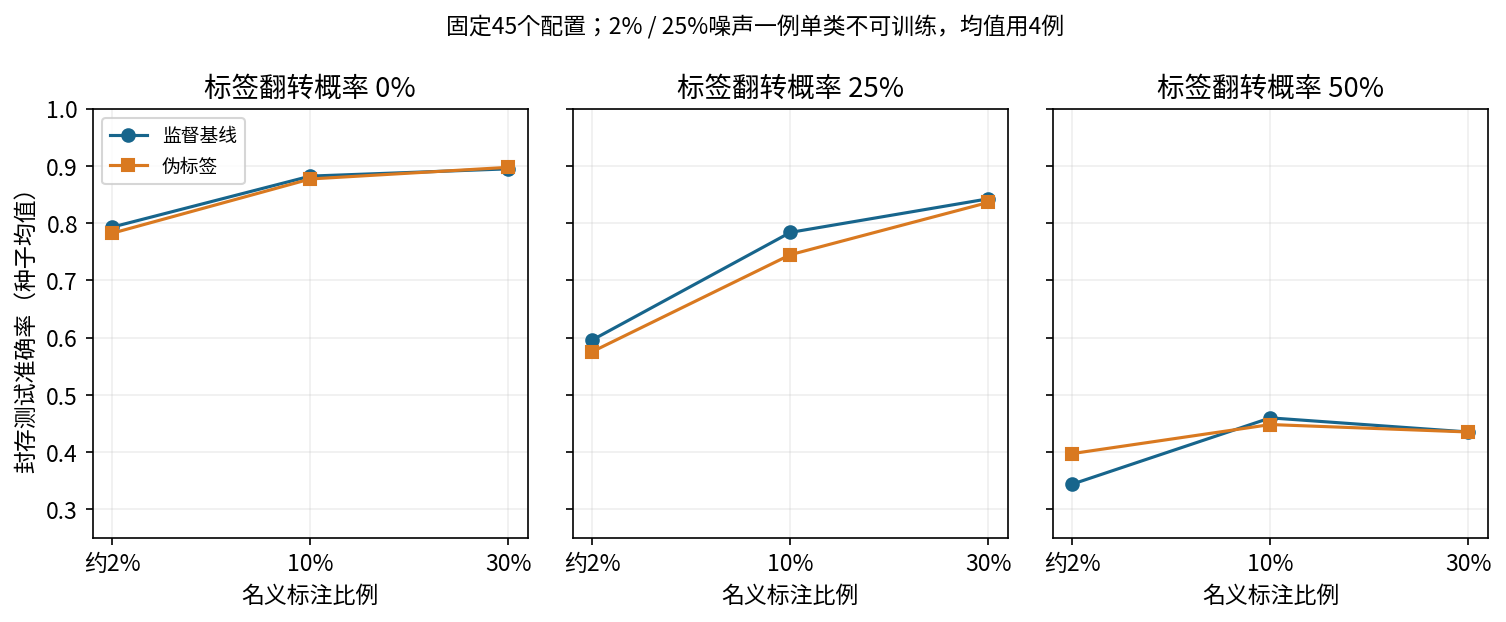

In [2]:
for row in r['summaries']: print(row)
print('不可训练:',[v for v in r['runs'] if v['status']!='ok'])
display(Image(filename='figures/03_results.png'))

逐轮审计: {
  "seed": 7,
  "ratio": 0.1,
  "noise": 0.25,
  "status": "ok",
  "label_count": 24,
  "actual_noise_fraction": 0.3333333333333333,
  "supervised": {
    "accuracy": 0.8533333333333334,
    "brier": 0.14052276433229713,
    "log_loss": 0.45195490159999013
  },
  "pseudo": {
    "accuracy": 0.84,
    "brier": 0.12375466279212517,
    "log_loss": 0.3931916994797307
  },
  "accuracy_change": -0.01333333333333342,
  "accepted": 126,
  "wrong_accepted": 9,
  "pseudo_error_rate": 0.07142857142857142,
  "history": [
    {
      "round": 1,
      "accepted_total": 24,
      "new_count": 24,
      "wrong_new": 0,
      "reason": "refit"
    },
    {
      "round": 2,
      "accepted_total": 73,
      "new_count": 49,
      "wrong_new": 1,
      "reason": "refit"
    },
    {
      "round": 3,
      "accepted_total": 110,
      "new_count": 37,
      "wrong_new": 2,
      "reason": "refit"
    },
    {
      "round": 4,
      "accepted_total": 123,
      "new_count": 13,
      "wrong_new

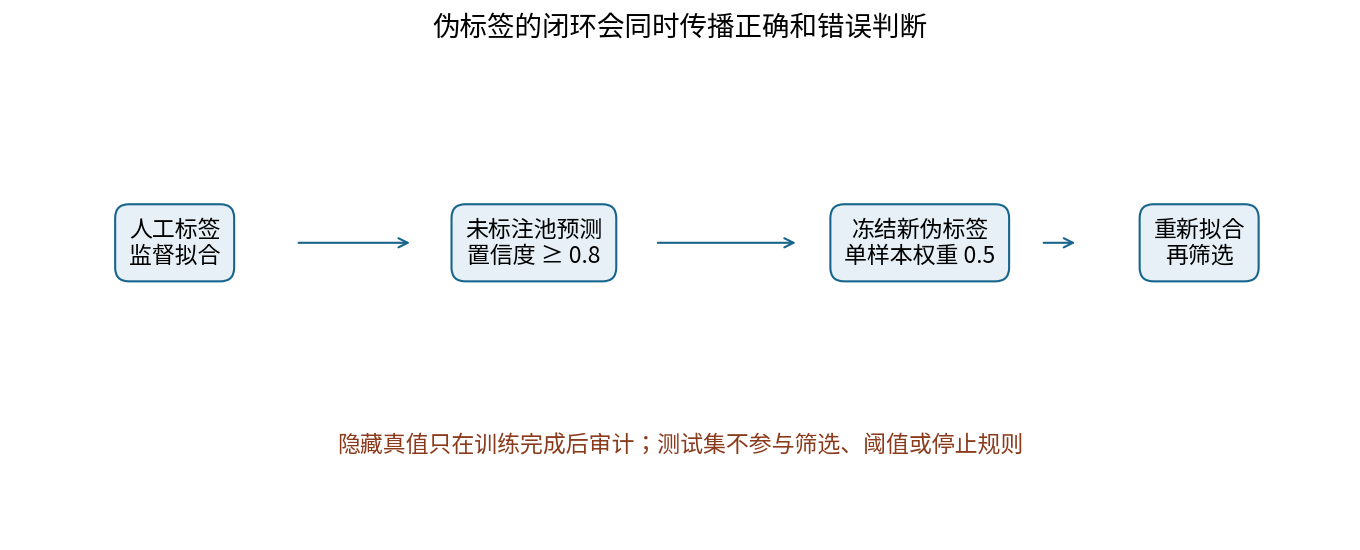

In [3]:
example=next(v for v in r['runs'] if v['seed']==7 and v['ratio']==.1 and v['noise']==.25)
print('逐轮审计:',json.dumps(example,ensure_ascii=False,indent=2))
display(Image(filename='figures/02_cycle.png'))

## 2 120个全错伪标签与置信度

{
  "description": "deliberately inverted seed labels; same sign-based underlying target",
  "accepted": 120,
  "wrong_accepted": 120,
  "stages": [
    {
      "stage": 0,
      "accuracy": 0.0,
      "mean_wrong_confidence": 0.9844316899646613,
      "coef": [
        -1.0409397145463708e-16,
        -1.99879426999935
      ]
    },
    {
      "stage": 1,
      "accuracy": 0.0,
      "mean_wrong_confidence": 0.9627829835189097,
      "coef": [
        2.4467060679884187e-16,
        -1.5361981674434522
      ]
    }
  ]
}


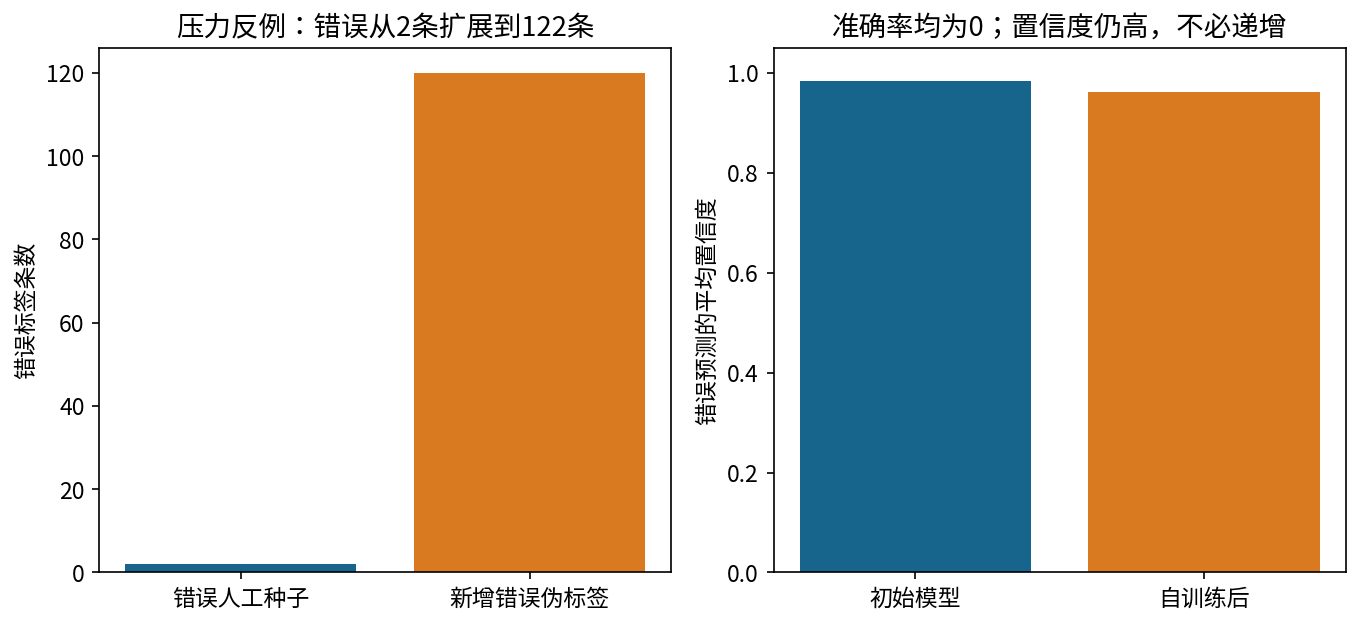

In [4]:
print(json.dumps(r['stress'],ensure_ascii=False,indent=2))
display(Image(filename='figures/04_reinforcement.png'))

## 3 弃权、冲突和复制规则

多数票: [-1 -1  1  0]
两票相抵: [0.5]
复制正票: [0.8]
弱标签审计: {'coverage': 0.8166666666666667, 'abstention_rate': 0.18333333333333332, 'covered_accuracy': 0.8622448979591837, 'conflict_rate': 0.17916666666666667, 'rule_coverage': [0.7708333333333334, 0.7583333333333333, 0.525], 'rule_accuracy': [0.9567567567567568, 0.8681318681318682, 0.5634920634920635], 'duplicate_conflict_rows': 9, 'independent_conflict_mean_confidence': 0.5, 'duplicate_conflict_mean_confidence': 0.8, 'assumed_accuracy': 0.8, 'assumption': 'given symmetric class accuracy; conditional independence; ignorable abstention; not learned from hidden labels'}


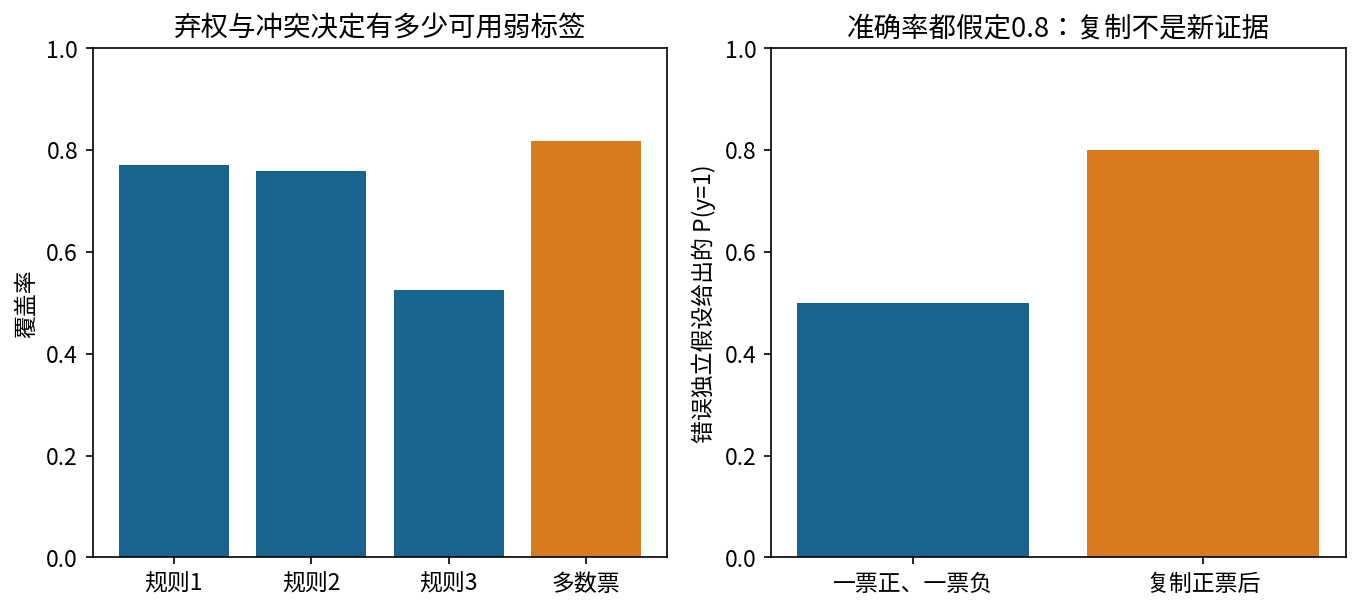

In [5]:
print('多数票:',majority_vote([[-1,-1],[0,1],[1,1],[0,-1]]))
print('两票相抵:',independent_label_probability([[1,0]],[.8,.8]))
print('复制正票:',independent_label_probability([[1,1,0]],[.8,.8,.8]))
print('弱标签审计:',r['weak_labels'])
display(Image(filename='figures/05_weak_labels.png'))

In [6]:
import unittest
from test_experiment import Checks
tests=unittest.TextTestRunner(verbosity=1).run(unittest.defaultTestLoader.loadTestsFromTestCase(Checks))
if not tests.wasSuccessful(): raise RuntimeError('tests failed')
print('全部测试通过；不代表无标签数据一定有帮助。')

全部测试通过；不代表无标签数据一定有帮助。


..........
----------------------------------------------------------------------
Ran 10 tests in 0.288s

OK


## 结论
训练与审计的信息分开。高置信度不是可靠性证明，重复规则不是新证据。